# Hemispherical asymmetry $A_\mathrm{LV}$

In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
import numpy as np
import healpy as hp
import polymv
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
load_stats_from_cluster = False
Nside_in   = 128
Nside_out  = 16
save_stats = True

# Settings for ALV
theta_deg         = 8
frac_to_be_masked = 0.1

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir  = "../../data/sims/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
names_Planck  = ["cleaned_70GHz_v9_nside_128",     "cleaned_94GHz_v9_nside_128", "cleaned_100GHz_v9_nside_128", "cleaned_143GHz_v9_nside_128",   "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128"]
labels_Planck = [      r"$70\, \mathrm{GHz}$",           r"$94\, \mathrm{GHz}$",       r"$100\, \mathrm{GHz}$",       r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]
colors_Planck = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [      "-",    "-",     "-",     "-",      "--",      "--",     "--",    "--"]
Nmaps = len(names_Planck)
index_Planck  = 4
index_Hayley  = 2

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]

markers     = ["s", "d", "o"]

if Nside_in ==  16: mask_files = ["stdv_mask_1percent_cutoff_0.9_nside_16.fits", "com_mask_cutoff_0.9_nside_16.fits"]
if Nside_in ==  64: mask_files = ["stdv_mask_1percent_cutoff_0.9_nside_64.fits", "com_mask_cutoff_0.9_nside_64.fits"]
if Nside_in == 128: mask_files = ["1percent_mask_v9.fits",                      "com_mask_cutoff_0.9_nside_128.fits"]
    
Nmasks = len(names_mask)

In [4]:
Npix_in  = hp.nside2npix(Nside_in)
Npix_out = hp.nside2npix(Nside_out)

In [5]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}
prop = {'family': 'Helvetica', 'size': 20}

In [6]:
masks = CMBanom.read_masks(masks_dir, mask_files, Nside_in)
masks_nan = np.where(np.array([mask for mask in masks])==0, np.NaN, 1)

In [7]:
# Read in maps in muK
maps_Planck = [hp.read_map(real_dir+"map_"+names_Planck[n]+".fits") for n in range(Nmaps)]
if Nside_in != 128: maps_Planck = np.array([CMBanom.downgrade_map(maps_Planck[n], Nside_in) for n in range(Nmaps)])

# Compute pixel lists and LV mask

In [8]:
pixlists = [CMBanom.get_pixlist(theta_deg, mask, Nside_in, Nside_out) for mask in masks]

In [9]:
lvmasks = np.array([CMBanom.get_lvmask(pixlists[m], theta_deg, frac_to_be_masked, Nside_in, Nside_out) for m in range(Nmasks)])
lvmasks_nan = np.array([np.where(lvmasks[m]==1., 1., np.nan) for m in range(Nmasks)])

# Compute LV maps and $A_\mathrm{LV}$

In [10]:
if load_stats_from_cluster:
    mean_lvmap = [hp.read_map(f"{stats_dir}meanlvmap_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
    var_lvmap  = [np.read_map(f"{stats_dir}varlvmap_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
    ALVs_sims  = np.array([np.loadtxt(stats_dir+f"ALV_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
else:
    maps_sims  = np.array([hp.read_map(sims_dir+f"map__{n}.fits") for n in range(Nsims)])
    if Nside_in != 128: maps_sims = np.array([CMBanom.downgrade_map(map, Nside_in) for map in maps_sims])

    lvmaps_sims = np.array([[CMBanom.get_lvmap(maps_sims[n], masks[m], pixlists[m], Nside_out) for n in range(Nsims)] for m in range(Nmasks)])
    mean_lvmaps = np.array([CMBanom.get_meanlvmap(lvmaps_sims[m], lvmasks[m]) for m in range(Nmasks)])
    var_lvmaps  = np.array([CMBanom.get_varlvmap(lvmaps_sims[m], lvmasks[m], mean_lvmaps[m]) for m in range(Nmasks)])
    ALVs_sims   = np.array([[CMBanom.ALV_vec(lvmaps_sims[m][n], lvmasks[m], mean_lvmaps[m], var_lvmaps[m])[0] for n in range(Nsims)] for m in range(Nmasks)])

In [11]:
lvmaps_Planck  = np.array([[CMBanom.get_lvmap(maps_Planck[n], masks[m], pixlists[m], Nside_out) for n in range(Nmaps)] for m in range(Nmasks)])
ALVs_Planck    = np.array([[CMBanom.ALV_vec(lvmaps_Planck[m][n], lvmasks[m], mean_lvmaps[m], var_lvmaps[m])[0] for n in range(Nmaps)] for m in range(Nmasks)])
dipvecs_Planck = np.array([[CMBanom.ALV_vec(lvmaps_Planck[m][n], lvmasks[m], mean_lvmaps[m], var_lvmaps[m])[1] for n in range(Nmaps)] for m in range(Nmasks)])

# Save stats to file 

In [12]:
if save_stats: np.save(stats_dir+"ALV_real", ALVs_Planck)

(3, 1000, 3072)
(3, 3072)
(3, 3072)
(3, 1000)
(3, 8, 3072)
(3, 3072)


# Plot LV maps

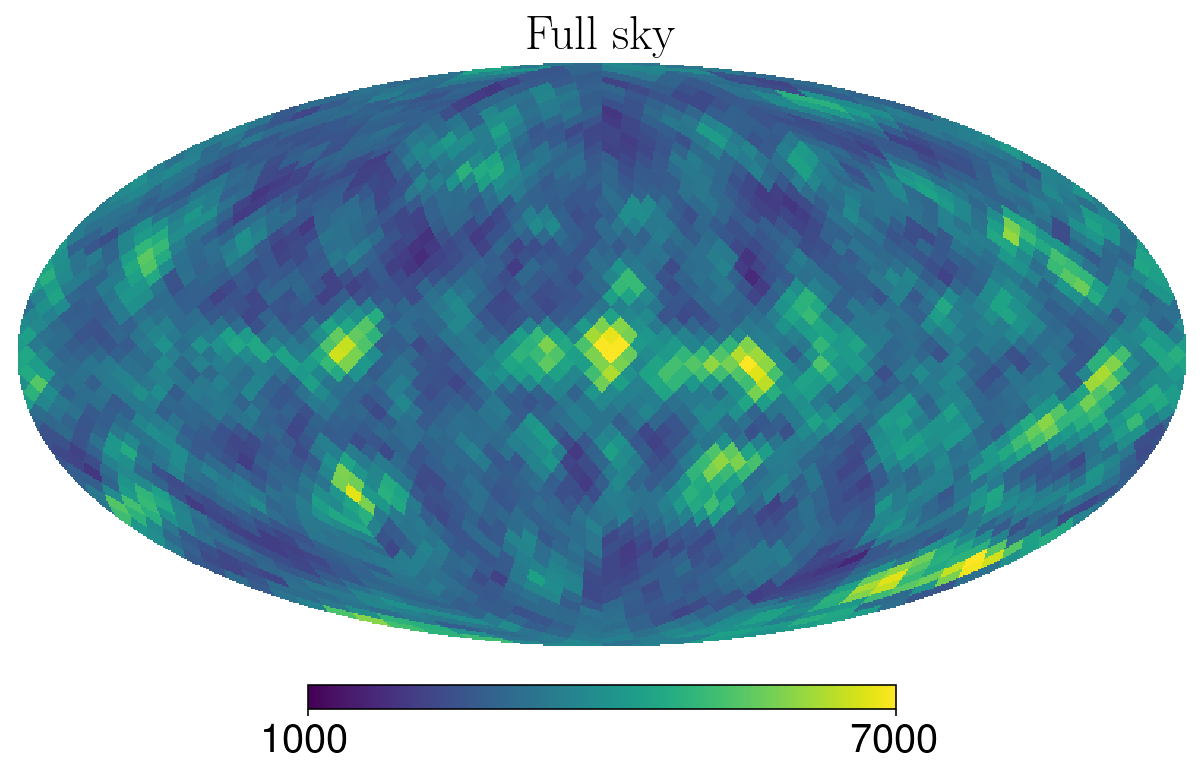

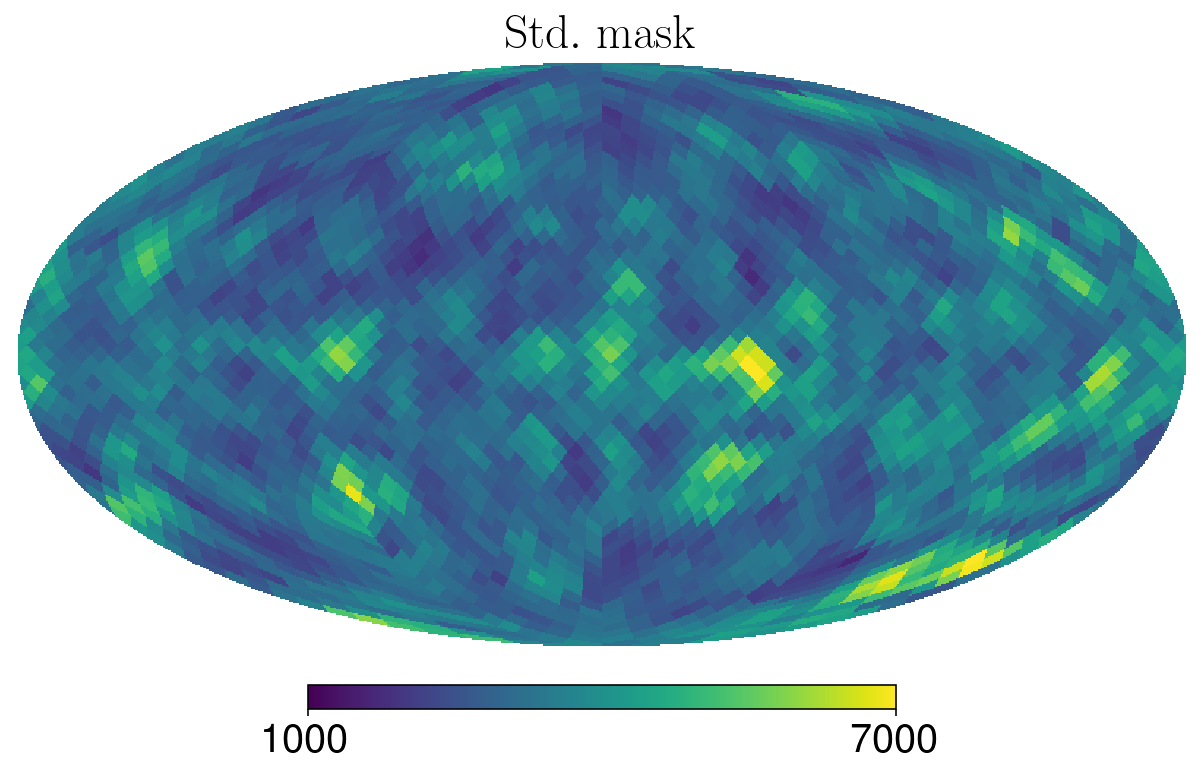

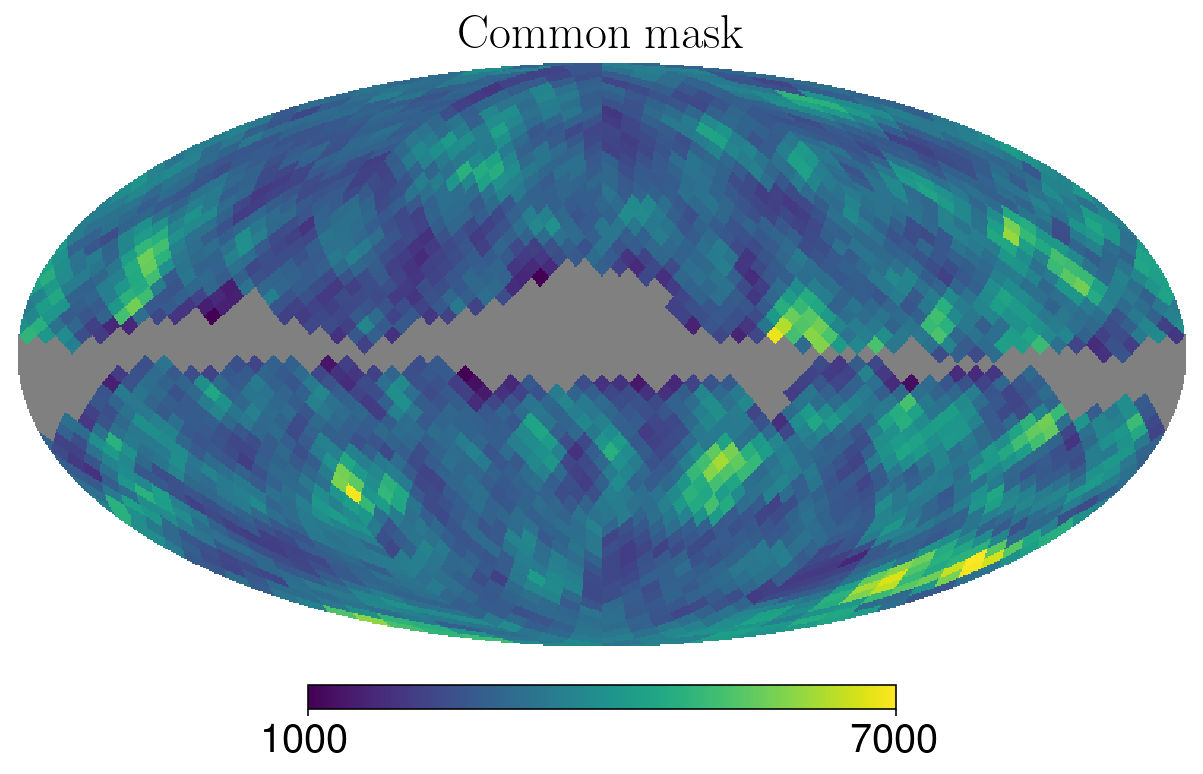

In [19]:
for m in range(Nmasks): hp.mollview(lvmaps_Planck[m][index_Hayley]*lvmasks_nan[m], title=labels_mask[m], min=1000, max=7000)

# Plot histograms

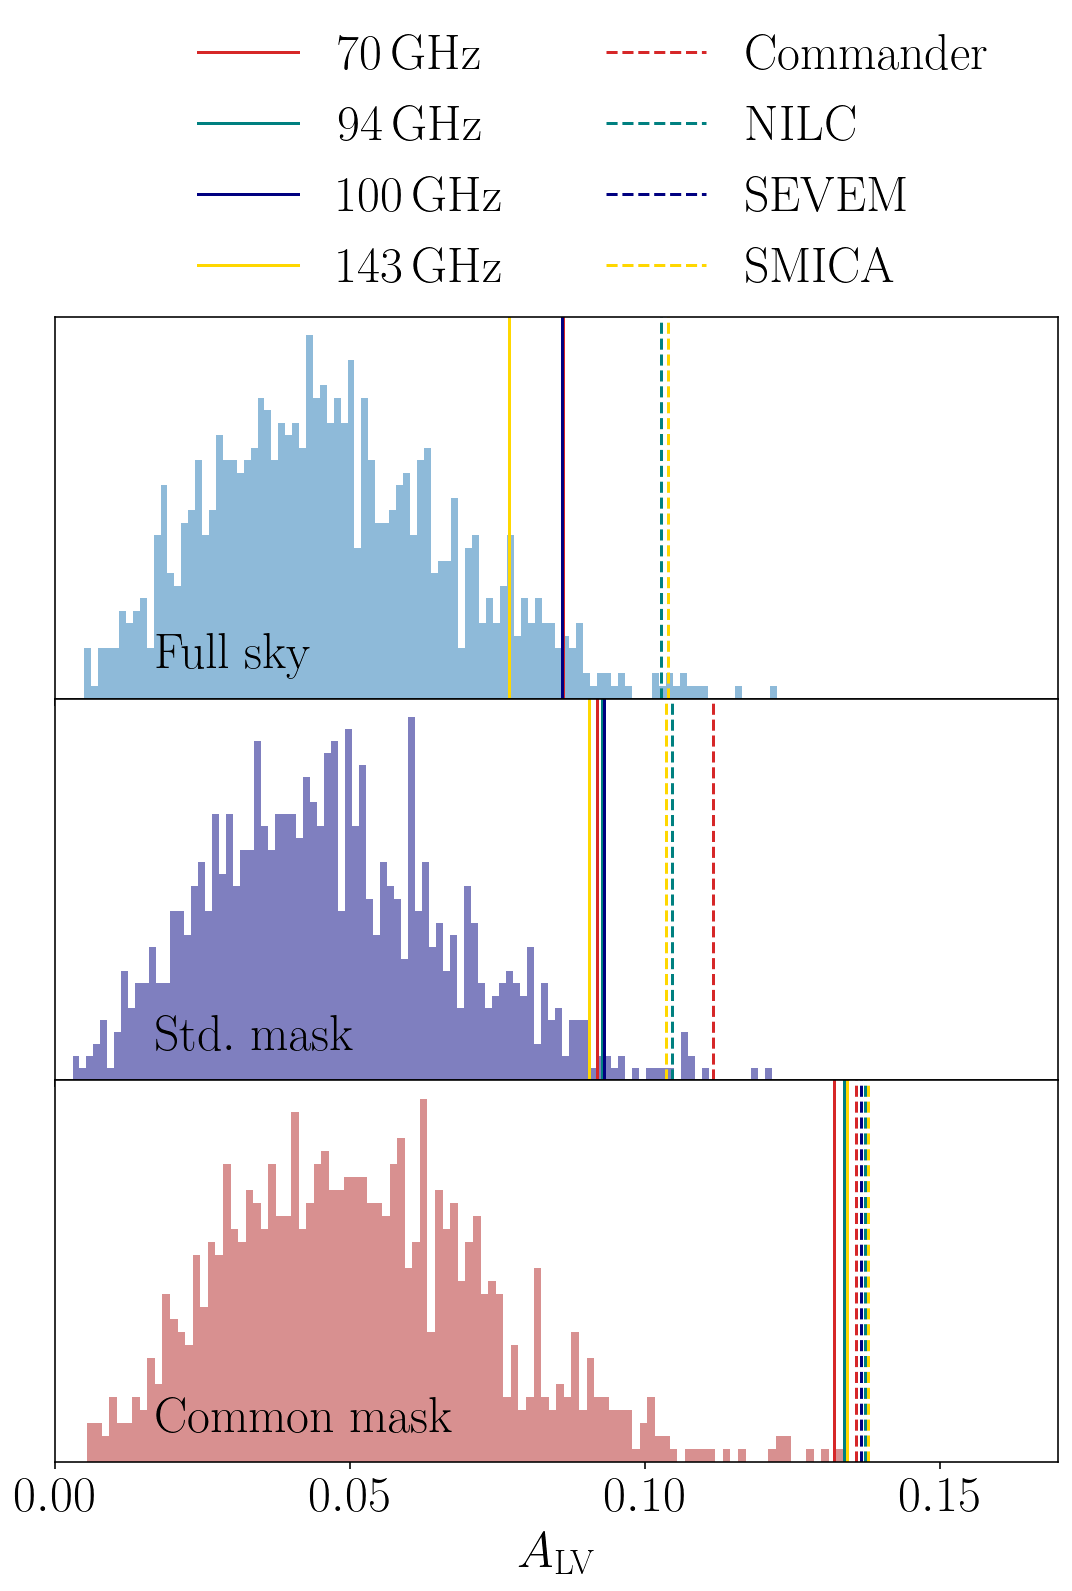

In [22]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].axvline(ALVs_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[m].hist(ALVs_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    
    axs[m].set_xlim(0, 0.17)
    axs[m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[m].text(0.1, 0.05, labels_mask[m], horizontalalignment='left', verticalalignment='bottom', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$A_\mathrm{LV}$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.17), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

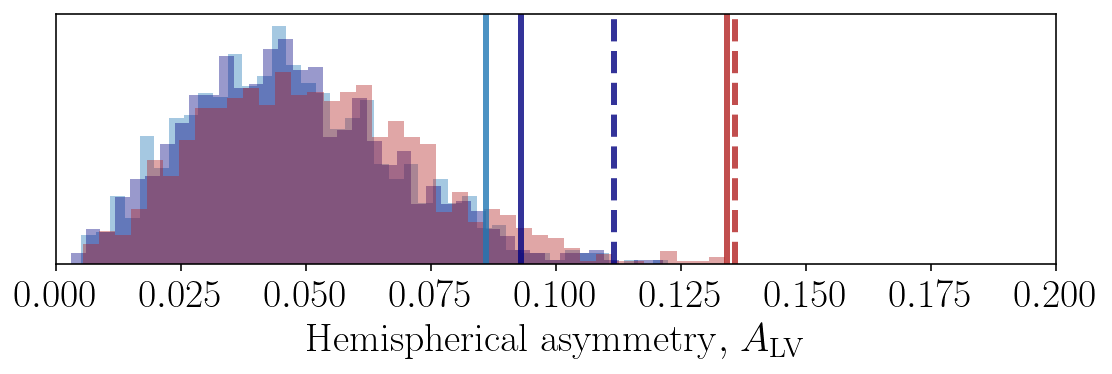

In [15]:
fig = plt.figure(figsize=(8, 3))
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(ALVs_sims[m], bins=40, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(ALVs_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(ALVs_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.xlim(0, 0.2)
plt.xlabel(r"$\mathrm{Hemispherical\ asymmetry,}\ A_\mathrm{LV}$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
#plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [16]:
pvals = [[CMBanom.pval_higher(ALVs_Planck[m][n], ALVs_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [17]:
for m in range(Nmasks):
    print("-----------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"ALV = {ALVs_Planck[m][n]:.2f}, p-value: {100*pvals[m][n]:.2f}% ({names_Planck[n]})")

-----------
fullsky
ALV = 0.09, p-value: 3.90% (cleaned_70GHz_v9_nside_128)
ALV = 0.21, p-value: 0.00% (cleaned_94GHz_v9_nside_128)
ALV = 0.09, p-value: 3.90% (cleaned_100GHz_v9_nside_128)
ALV = 0.08, p-value: 9.10% (cleaned_143GHz_v9_nside_128)
ALV = 0.30, p-value: 0.00% (commander_nside_128)
ALV = 0.10, p-value: 1.10% (nilc_nside_128)
ALV = 0.61, p-value: 0.00% (sevem_nside_128)
ALV = 0.10, p-value: 1.00% (smica_nside_128)
-----------
stdmask
ALV = 0.09, p-value: 2.10% (cleaned_70GHz_v9_nside_128)
ALV = 0.09, p-value: 2.00% (cleaned_94GHz_v9_nside_128)
ALV = 0.09, p-value: 1.90% (cleaned_100GHz_v9_nside_128)
ALV = 0.09, p-value: 2.20% (cleaned_143GHz_v9_nside_128)
ALV = 0.11, p-value: 0.20% (commander_nside_128)
ALV = 0.10, p-value: 1.00% (nilc_nside_128)
ALV = 0.19, p-value: 0.00% (sevem_nside_128)
ALV = 0.10, p-value: 1.00% (smica_nside_128)
-----------
commask
ALV = 0.13, p-value: 0.10% (cleaned_70GHz_v9_nside_128)
ALV = 0.13, p-value: 0.10% (cleaned_94GHz_v9_nside_128)
ALV = 0.13

# Plot directions of LV dipole

In [18]:
for n in range(Nmaps):
    m = 1
    hp.mollview(normlvmaps_Planck[m][n]*lvmasks[m], min=-2, max=2, title=labels_Planck[n])
    for m in range(Nmasks):
        theta, phi = hp.vec2ang(dipvecs_Planck[m][n])
        hp.projscatter(theta, phi, color="tab:red", marker=markers[m], label=labels_mask[m])
    plt.legend()

NameError: name 'normlvmaps_Planck' is not defined

In [ ]:
m = 1
hp.mollview(normlvmaps_Planck[m][index_Hayley]*lvmasks_nan[m], min=-2, max=2, title=labels_Planck[index_Hayley], unit=r"$\mathrm{Normalized\ local\ variance}$")
hp.graticule()
for m in range(Nmasks):
    for n in range(Nmaps):
        theta, phi = hp.vec2ang(dipvecs_Planck[m][n])
        if (m==1): label = labels_Planck[n];
        else: label=None
        if n>3: hp.projscatter(theta, phi, marker=markers[m], color=colors_Planck[n], label=label)
        else:   hp.projscatter(theta, phi, marker=markers[m], color="teal", edgecolor=colors_Planck[n], label=label)
plt.legend()
plt.show()

In [ ]:
lens_pixlist = np.array([[len(list) for list in pixlists[m]] for m in range(Nmasks)])
for m in range(Nmasks): hp.mollview(lens_pixlist[m]*lvmasks_nan[m], title=labels_mask[m])

In [ ]:
print("Sims")
print("Monopole, dipole amplitude")
for n in range(Nmaps): print(hp.remove_dipole(maps_sims[n], fitval = True)[1], np.linalg.norm(hp.remove_dipole(maps_sims[n], fitval = True)[2]))
print("--------")    
print("Real")
print("Monopole, dipole amplitude")
for n in range(Nmaps): print(hp.remove_dipole(maps_Planck[n], fitval = True)[1], np.linalg.norm(hp.remove_dipole(maps_Planck[n], fitval = True)[2]))

In [ ]:
print("hp.remove_dipole [monopole, dipole]")
for n in range(Nmaps):
    m = hp.ma(maps_Planck[n])
    m.mask = np.logical_not(masks[1])
    print(hp.remove_dipole(m, fitval = True)[1], np.linalg.norm(hp.remove_dipole(m, fitval = True)[2]), names_Planck[n])
    #print(np.nanmean(m))

In [ ]:
print("hp.remove_dipole [monopole, dipole]")
for n in range(Nmaps):
    m = maps_Planck[n]*masks_nan[1]
    print(np.nanmean(m))
#    print(hp.remove_dipole(m, fitval = True)[1], np.linalg.norm(hp.remove_dipole(m, fitval = True)[2]), names_Planck[n])

In [ ]:
mask[1]